# DDoS Auswertung

## Imports

In [1]:
import subprocess
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

## Globale Parameter

In [2]:
SERVER_IP = "141.22.28.227"

## 1. Parsen der Dateien

In [3]:
schema_overrides = {
        "frame.time": pl.Datetime,
        "frame.time_epoch": pl.Float64,
        "frame.len": pl.Int64,
        "tcp.srcport": pl.Int64,
        "tcp.dstport": pl.Int64,
        "udp.srcport": pl.Int64,
        "udp.dstport": pl.Int64,
}

SMALL_FIELDS = [
    "frame.time",
    "frame.time_epoch",
    "frame.len",
    "frame.protocols",
    "ip.proto",
    "ip.src",
    "ip.dst",
    "tcp.srcport",
    "tcp.dstport",
    "udp.srcport",
    "udp.dstport",
]

In [4]:
def pcap_to_parquet(input_file: Path, output_file: Path, batch_size: int = 500_000) -> None:
    csv_path = output_file.with_suffix(".csv")
    cmd = ["tshark", "-r", str(input_file), "-T", "fields"]
    for f in SMALL_FIELDS:
        cmd += ["-e", f]
    cmd += ["-E", "header=y", "-E", "separator=,", "-E", "quote=d", "-E", "occurrence=f"]

    with open(csv_path, "wb") as f:
        result = subprocess.run(cmd, stdout=f, stderr=subprocess.PIPE)
    if result.returncode != 0:
        csv_path.unlink(missing_ok=True)
        raise RuntimeError(result.stderr.decode())

    lf = pl.scan_csv(csv_path, schema_overrides=schema_overrides, null_values=[""])

    writer = None
    try:
        for batch in lf.collect_batches(chunk_size=batch_size):
            table = batch.to_arrow()
            if writer is None:
                writer = pq.ParquetWriter(output_file, table.schema)
            writer.write_table(table)
    finally:
        if writer is not None:
            writer.close()

    csv_path.unlink()

In [5]:
input_file = Path("data/raw/2025-08-13_15-38CEST_ddos-event_full-packets_100MiB.pcap.zst")
output_file = Path("data/interim/2025-08-13_15-38CEST_ddos-event_full-packets_100MiB.parquet")
df = pcap_to_parquet(input_file, output_file)

## 2. Analyse der Daten

### 2.1 Überblick über die Daten (raw)

In [6]:
lf = pl.scan_parquet(output_file)
df_sample = lf.limit(100).collect().sample(10)
df_sample

frame.time,frame.time_epoch,frame.len,frame.protocols,ip.proto,ip.src,ip.dst,tcp.srcport,tcp.dstport,udp.srcport,udp.dstport
datetime[μs],f64,i64,str,i64,str,str,i64,i64,i64,i64
2025-08-13 13:28:28.354835,1.7551e9,482,"""eth:ethertype:ip:udp:ntp""",17,"""68.168.214.83""","""141.22.28.227""",null,null,123,64219
2025-08-13 13:28:28.355468,1.7551e9,397,"""eth:ethertype:ip:udp:data""",17,"""202.186.83.214""","""141.22.28.227""",null,null,50351,39215
2025-08-13 13:28:28.355576,1.7551e9,482,"""eth:ethertype:ip:udp:ntp""",17,"""68.168.214.83""","""141.22.28.227""",null,null,123,64219
2025-08-13 13:28:28.355973,1.7551e9,1335,"""eth:ethertype:ip:udp:coap""",17,"""39.65.20.246""","""141.22.28.227""",null,null,5683,8947
2025-08-13 13:28:28.356028,1.7551e9,482,"""eth:ethertype:ip:udp:ntp""",17,"""189.91.0.69""","""141.22.28.227""",null,null,123,40619
2025-08-13 13:28:28.356152,1.7551e9,482,"""eth:ethertype:ip:udp:ntp""",17,"""189.91.0.69""","""141.22.28.227""",null,null,123,40619
2025-08-13 13:28:28.356212,1.7551e9,412,"""eth:ethertype:ip:udp:data""",17,"""116.233.137.183""","""141.22.28.227""",null,null,55606,15930
2025-08-13 13:28:28.356567,1.7551e9,412,"""eth:ethertype:ip:udp:data""",17,"""182.111.75.162""","""141.22.28.227""",null,null,57149,22196
2025-08-13 13:28:28.356748,1.7551e9,987,"""eth:ethertype:ip:udp:snmp:snmp…",17,"""185.220.80.67""","""141.22.28.227""",null,null,161,18127


### 2.1.2 hinzufügen von Daten

In [7]:
# read IANA list to convert number to text
lf_pro_nb = (
    pl.scan_csv("data/external/protocol-numbers-1.csv", ignore_errors=True)
      .select("Decimal", "Keyword")
).rename({"Keyword": "ip.proto.name", "Decimal": "ip.proto.num"})
lf_pro_nb.head(10).collect()

ip.proto.num,ip.proto.name
i64,str
0,"""HOPOPT"""
1,"""ICMP"""
2,"""IGMP"""
3,"""GGP"""
4,"""IPv4"""
5,"""ST"""
6,"""TCP"""
7,"""CBT"""
8,"""EGP"""


In [8]:
lf = (
    lf.join(lf_pro_nb, left_on="ip.proto", right_on="ip.proto.num", how="left")
    .rename({"ip.proto": "ip.proto.num"})
    .pipe(lambda lf: lf.select(
    (cols := lf.collect_schema().names(), cols.insert(5, cols.pop(cols.index("ip.proto.name"))), cols)[-1]
))
)

lf.head(10).collect()

frame.time,frame.time_epoch,frame.len,frame.protocols,ip.proto.num,ip.proto.name,ip.src,ip.dst,tcp.srcport,tcp.dstport,udp.srcport,udp.dstport
datetime[μs],f64,i64,str,i64,str,str,str,i64,i64,i64,i64
2025-08-13 13:28:28.354835,1.7551e9,482,"""eth:ethertype:ip:udp:ntp""",17,"""UDP""","""68.168.214.83""","""141.22.28.227""",null,null,123,64219
2025-08-13 13:28:28.354835,1.7551e9,443,"""eth:ethertype:ip:udp:data""",17,"""UDP""","""85.113.53.151""","""141.22.28.227""",null,null,49928,15561
2025-08-13 13:28:28.354922,1.7551e9,1514,"""eth:ethertype:ip:data""",17,"""UDP""","""199.172.240.213""","""141.22.28.227""",null,null,null,null
2025-08-13 13:28:28.354922,1.7551e9,407,"""eth:ethertype:ip:udp:data""",17,"""UDP""","""102.152.183.249""","""141.22.28.227""",null,null,59480,23984
2025-08-13 13:28:28.355004,1.7551e9,619,"""eth:ethertype:ip:udp:xml""",17,"""UDP""","""66.170.190.104""","""141.22.28.227""",null,null,3702,32994
2025-08-13 13:28:28.355092,1.7551e9,940,"""eth:ethertype:ip:data""",17,"""UDP""","""160.250.5.142""","""141.22.28.227""",null,null,null,null
2025-08-13 13:28:28.355183,1.7551e9,541,"""eth:ethertype:ip:udp:ssdp""",17,"""UDP""","""114.230.110.29""","""141.22.28.227""",null,null,1900,52238
2025-08-13 13:28:28.355183,1.7551e9,407,"""eth:ethertype:ip:udp:data""",17,"""UDP""","""102.152.175.124""","""141.22.28.227""",null,null,39227,10445
2025-08-13 13:28:28.355183,1.7551e9,411,"""eth:ethertype:ip:udp:data""",17,"""UDP""","""41.226.182.16""","""141.22.28.227""",null,null,49188,53989


### 2.2 Datenübersicht

#### 2.2.1 Incoming vs. Outgoing

In [9]:
def split_direction(lf: pl.LazyFrame, server_ip):
    lf_out = lf.filter(pl.col("ip.src") == server_ip)
    lf_in = lf.filter(pl.col("ip.dst") == server_ip)
    lf_null = lf.filter(
        (pl.col("ip.dst") != server_ip) & (pl.col("ip.src") != server_ip)
    )
    lf_null = lf.filter(
        pl.col("ip.src").is_null() | pl.col("ip.dst").is_null()
    )
    print("lf_out:")
    lf_out.head(10).collect().show()
    
    return lf_out, lf_in, lf_null

In [10]:
lf_out, lf_in, lf_null = split_direction(lf, SERVER_IP)

lf_out:


frame.time,frame.time_epoch,frame.len,frame.protocols,ip.proto.num,ip.proto.name,ip.src,ip.dst,tcp.srcport,tcp.dstport,udp.srcport,udp.dstport
datetime[μs],f64,i64,str,i64,str,str,str,i64,i64,i64,i64
2025-08-13 13:28:28.358705,1.7551e9,510,"""eth:ethertype:ip:icmp:ip:udp:n…",1,"""ICMP""","""141.22.28.227""","""68.168.223.169""",null,null,123,22691
2025-08-13 13:28:28.358710,1.7551e9,428,"""eth:ethertype:ip:icmp:ip:udp:d…",1,"""ICMP""","""141.22.28.227""","""190.74.24.222""",null,null,47865,63500
2025-08-13 13:28:28.358764,1.7551e9,453,"""eth:ethertype:ip:icmp:ip:udp:d…",1,"""ICMP""","""141.22.28.227""","""95.78.175.81""",null,null,57711,7217
2025-08-13 13:28:28.358768,1.7551e9,590,"""eth:ethertype:ip:icmp:ip:udp:s…",1,"""ICMP""","""141.22.28.227""","""171.234.79.146""",null,null,161,62133
2025-08-13 13:28:28.358815,1.7551e9,421,"""eth:ethertype:ip:icmp:ip:udp:d…",1,"""ICMP""","""141.22.28.227""","""82.209.78.44""",null,null,39288,28671


#### 2.2.2 Transport Protokoll

In [11]:
def split_transport(lf: pl.LazyFrame) -> tuple[pl.LazyFrame, ...]:
    protos = lf.select("ip.proto.num").unique().collect()["ip.proto.num"].to_list()
    return tuple(
        lf.filter(
            pl.col("ip.proto.num").is_null() if proto is None
            else pl.col("ip.proto.num") == proto
        )
        for proto in protos
    )

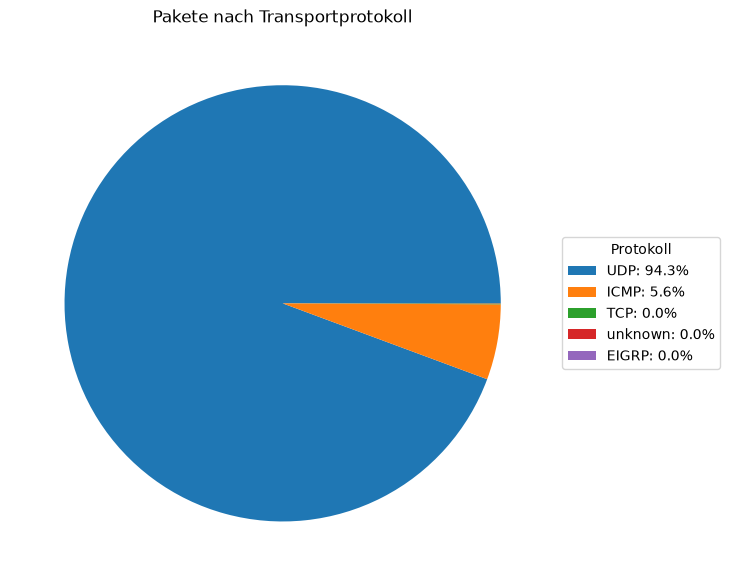

In [12]:
counts = (
    lf.group_by("ip.proto.num")
    .agg(pl.len().alias("count"))
    .collect()
    .sort("count", descending=True)
)

proto_names = {6: "TCP", 17: "UDP", 1: "ICMP", 88: "EIGRP", None: "unknown"}
total = counts["count"].sum()

labels = [
    f"{proto_names.get(p, str(p))}: {c/total*100:.1f}%"
    for p, c in zip(counts["ip.proto.num"], counts["count"])
]

fig, ax = plt.subplots(figsize=(7, 6))
wedges, _ = ax.pie(counts["count"])
ax.set_title("Pakete nach Transportprotokoll")
ax.legend(wedges, labels, title="Protokoll", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [13]:
total_packets: int  = lf.select(pl.len()).collect().item()
total_bytes: int = lf.select(pl.col("frame.len").sum()).collect().item()

t_start = lf.select(pl.col("frame.time").min()).collect().item()
t_end = lf.select(pl.col("frame.time").max()).collect().item()
duration_s = (t_end - t_start).total_seconds()

print(f"Pakete gesamt : {total_packets:>12,}")
print(f"Bytes gesamt  : {total_bytes:>12,}  ({total_bytes/1e6:.1f} MB)")
print(f"Zeitraum      : {t_start}  →  {t_end}")
print(f"Dauer         : {duration_s:.1f} s")
print(f"Ø Paketrate   : {total_packets/duration_s:>10,.1f} pkt/s")
print(f"Ø Bitrate     : {total_bytes*8/duration_s/1e6:>10,.1f} Mbit/s")

Pakete gesamt :      186,212
Bytes gesamt  :   97,022,383  (97.0 MB)
Zeitraum      : 2025-08-13 13:28:28.354835  →  2025-08-13 13:28:41.138751
Dauer         : 12.8 s
Ø Paketrate   :   14,566.1 pkt/s
Ø Bitrate     :       60.7 Mbit/s


### Packets/Bytes per Second

In [14]:
df_in_per_sec = (
    lf_in.with_columns(pl.col("frame.time_epoch").cast(pl.Int64).alias("ts"))
    .group_by(pl.col("ts"))
    .agg([
        pl.len().alias("packets"),
        pl.col("frame.len").sum().alias("bytes"),
    ])
    .sort("ts")
    .collect()
)

df_in_per_sec.head(20)

ts,packets,bytes
i64,u64,i64
1755091708,16428,9238916
1755091709,19237,10892725
1755091710,17288,9487156
1755091711,15585,8178871
1755091712,14518,7512168
…,…,…
1755091717,11350,5824107
1755091718,11146,5681099
1755091719,9984,4938980


## 5. Top-Talker (meiste Pakete / meiste Bytes)

In [15]:
top_talkers = (
    lf.group_by("ip.src")
    .agg([
        pl.len().alias("packets"),
        pl.col("frame.len").sum().alias("bytes"),
    ])
    .sort("bytes", descending=True)
    .collect()
)

top_talkers.head(20)

ip.src,packets,bytes
str,u64,i64
"""141.22.28.227""",10408,4616742
"""49.176.212.229""",1685,812170
"""208.82.127.233""",1500,723000
"""173.245.226.45""",1400,674800
"""201.168.4.30""",1400,674800
…,…,…
"""201.168.193.30""",800,385600
"""167.88.48.3""",800,385600
"""80.58.201.52""",800,385600


## 7. Amplification-Metriken (BAF/PAF), optional

Falls Request/Response anhand `coap.code` oder Port-Richtung unterschieden werden können, hier die Grundstruktur. An eure CoAP-Logik anpassen (z. B. Server-Port als Filter, GET-Request vs. Response).

In [16]:
SERVER_PORT = 5683  # ggf. anpassen

requests = lf.filter(pl.col("udp.dstport") == SERVER_PORT)
responses = lf.filter(pl.col("udp.srcport") == SERVER_PORT)

req_stats = requests.select([
    pl.len().alias("req_packets"),
    pl.col("frame.len").sum().alias("req_bytes"),
]).collect()

resp_stats = responses.select([
    pl.len().alias("resp_packets"),
    pl.col("frame.len").sum().alias("resp_bytes"),
]).collect()

baf = resp_stats["resp_bytes"][0] / req_stats["req_bytes"][0]
paf = resp_stats["resp_packets"][0] / req_stats["req_packets"][0]

print(f"BAF (Bandwidth Amplification Factor): {baf:.2f}")
print(f"PAF (Packet Amplification Factor):   {paf:.2f}")

BAF (Bandwidth Amplification Factor): 47270.96
PAF (Packet Amplification Factor):   4011.00
